# Notebook 05 — Advanced Models

**Project:** Boston Marathon BQ Predictor  
**Author:** Gian Marco  
**Date:** April 2026

## Objectives

1. Train Random Forest and XGBoost with reasonable hyperparameters (no exhaustive tuning at this stage)
2. Compare them with the baselines from Notebook 04 using the same metrics
3. Identify the strongest candidate model for the next notebooks
4. Leave GridSearch tuning for a later iteration

## Fundamental Rule

The same rule still applies: `test_features.csv` is NOT used in this notebook. All comparisons are performed via cross-validation on `train_features.csv`.

## Evaluation Metric

**F1-score of the positive class (BQ=1).** The same complementary metrics from Notebook 04 are also reported.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup ready')
print(f'XGBoost version: {xgb.__version__}')

Setup ready
XGBoost version: 3.2.0


---
## 1. Load Data and Cross-Validation Setup

We reuse exactly the same cross-validation configuration from Notebook 04 to ensure results are directly comparable.

In [2]:
TRAIN_DIR = Path('../data/train')
train = pd.read_csv(TRAIN_DIR / 'train_features.csv')

X = train.drop(columns=['es_BQ'])
y = train['es_BQ']

if 'Year' in X.columns:
    X = X.drop(columns=['Year'])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_pos': 'f1',
    'precision_pos': 'precision',
    'recall_pos': 'recall',
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
}

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'BQ rate: {y.mean()*100:.2f}%')

X shape: (225356, 22)
y shape: (225356,)
BQ rate: 13.45%


---
## 2. Helper to Summarize Results

We reuse the same function from Notebook 04 to ensure the final consolidated table remains consistent across notebooks.

In [3]:
def summarize_cv(cv_results, model_name):
    summary = {'model': model_name}
    for metric in scoring.keys():
        key = f'test_{metric}'
        summary[f'{metric}_mean'] = cv_results[key].mean()
        summary[f'{metric}_std'] = cv_results[key].std()
    summary['fit_time_mean'] = cv_results['fit_time'].mean()
    return summary

results = []
print('Helper ready')

Helper ready


---
## 3. Random Forest

Configuration:
- `n_estimators=200` — 200 trees, a good speed/performance trade-off  
- `max_depth=None` — no depth limit; the ensemble mitigates individual overfitting  
- `min_samples_leaf=20` — prevents overly noisy leaves (less restrictive than Decision Tree due to averaging across many trees)  
- `n_jobs=-1` — full parallelization  
- `random_state=42`  

We do not apply `class_weight='balanced'` yet — this will be tested in Notebook 06 to isolate its effect.

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Training Random Forest (may take ~1–2 minutes)...')
cv_out = cross_validate(rf, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'RandomForest (200 trees, leaf=20)')
results.append(summary)

print(f"\nF1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

Training Random Forest (may take ~1–2 minutes)...

F1 (positive class):  0.1306 ± 0.0075
Precision:            0.5926
Recall:               0.0734
PR-AUC:               0.3329
ROC-AUC:              0.7270
Average fit time:     20.76s


---
## 4. XGBoost

Configuration:
- `n_estimators=200` — 200 sequential trees  
- `max_depth=6` — moderate depth (typical XGBoost default)  
- `learning_rate=0.1` — contribution of each new tree  
- `tree_method='hist'` — modern, efficient algorithm for large datasets  
- `eval_metric='logloss'` — internal training metric  
- `random_state=42`  

In [5]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Training XGBoost (may take ~30–60s)...')
cv_out = cross_validate(xgb_model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost (200 trees, depth=6, lr=0.1)')
results.append(summary)

print(f"\nF1 (positive class):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:            {summary['precision_pos_mean']:.4f}")
print(f"Recall:               {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:               {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:              {summary['roc_auc_mean']:.4f}")
print(f"Average fit time:     {summary['fit_time_mean']:.2f}s")

Training XGBoost (may take ~30–60s)...

F1 (positive class):  0.1667 ± 0.0072
Precision:            0.5564
Recall:               0.0981
PR-AUC:               0.3356
ROC-AUC:              0.7361
Average fit time:     1.85s


---
## 5. Consolidated Comparison Table — Baselines + Advanced Models

We load the results from Notebook 04 and combine them with the results from this notebook to create a unified comparison.

In [6]:
# Load baseline results from Notebook 04
baseline_results = pd.read_csv(PROCESSED_DATA_DIR / 'baseline_results.csv')

# Add results from this notebook
current_results_df = pd.DataFrame(results)
all_results = pd.concat([baseline_results, current_results_df], ignore_index=True)

# Sort by F1 descending
all_results = all_results.sort_values('f1_pos_mean', ascending=False).reset_index(drop=True)

# Clean table for display
metric_cols = ['f1_pos_mean', 'precision_pos_mean', 'recall_pos_mean', 'pr_auc_mean', 'roc_auc_mean']
display_df = all_results[['model'] + metric_cols + ['fit_time_mean']].copy()
display_df.columns = ['Model', 'F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC', 'Fit (s)']

for col in ['F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df['Fit (s)'] = display_df['Fit (s)'].apply(lambda x: f'{x:.2f}')

print('CONSOLIDATED RANKING (baselines + advanced models)')
print('=' * 100)
print(display_df.to_string(index=False))

CONSOLIDATED RANKING (baselines + advanced models)
                               Model F1 (pos) Precision Recall PR-AUC ROC-AUC Fit (s)
XGBoost (200 trees, depth=6, lr=0.1)   0.1667    0.5564 0.0981 0.3356  0.7361    1.85
                  LogisticRegression   0.1666    0.5488 0.0982 0.3276  0.7286    0.52
     DecisionTree (depth=8, leaf=50)   0.1506    0.5693 0.0870 0.3263  0.7316    0.32
                  Dummy (stratified)   0.1378    0.1380 0.1376 0.1350  0.5020    0.04
   RandomForest (200 trees, leaf=20)   0.1306    0.5926 0.0734 0.3329  0.7270   20.76
               Dummy (most_frequent)   0.0000    0.0000 0.0000 0.1345  0.5000    0.08


---
## 6. Comparative Visualization

Bar chart comparing the 6 models across the 3 key metrics. It should visually show that F1 remains relatively limited, while PR-AUC and ROC-AUC improve slightly with the advanced models.

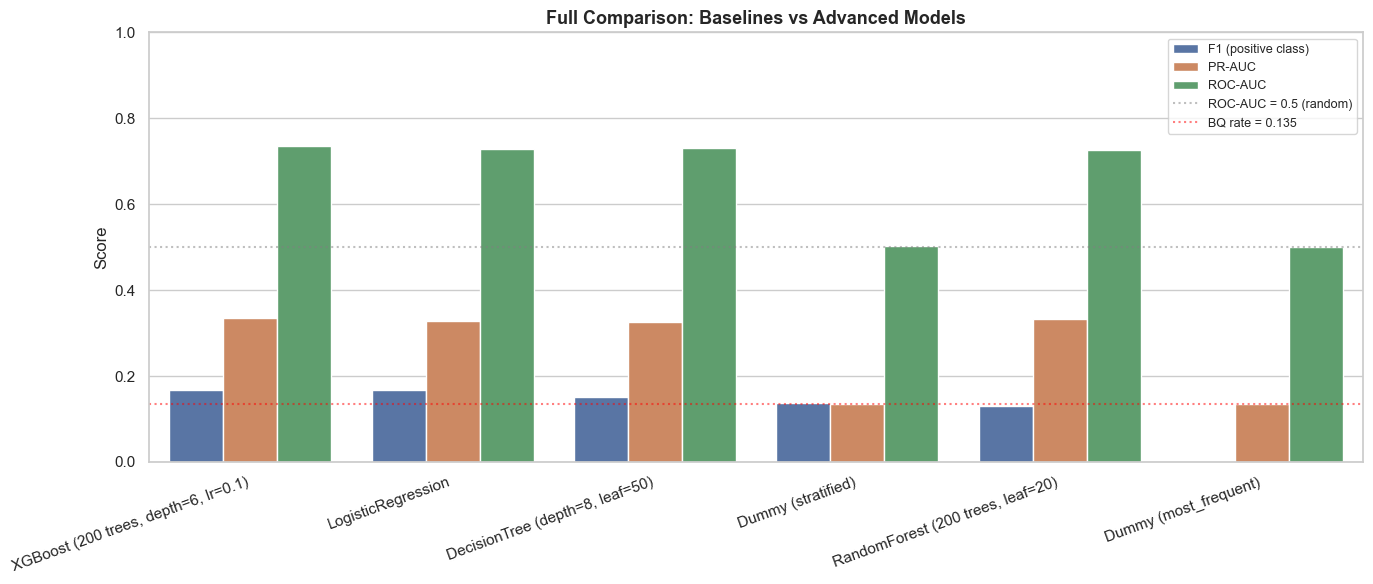

In [7]:
plot_df = all_results[['model', 'f1_pos_mean', 'pr_auc_mean', 'roc_auc_mean']].copy()
plot_df = plot_df.melt(id_vars='model', var_name='metric', value_name='score')
plot_df['metric'] = plot_df['metric'].map({
    'f1_pos_mean': 'F1 (positive class)',
    'pr_auc_mean': 'PR-AUC',
    'roc_auc_mean': 'ROC-AUC',
})

model_order = all_results['model'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=plot_df,
    x='model',
    y='score',
    hue='metric',
    order=model_order,
    palette='deep',
    ax=ax,
    edgecolor='white'
)

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='ROC-AUC = 0.5 (random)')
ax.axhline(y.mean(), color='red', linestyle=':', alpha=0.5, label=f'BQ rate = {y.mean():.3f}')

ax.set_title(
    'Full Comparison: Baselines vs Advanced Models',
    fontweight='bold',
    fontsize=13
)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_advanced_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Save Consolidated Results

In [8]:
all_results.to_csv(PROCESSED_DATA_DIR / 'advanced_results.csv', index=False)

print(f'Results saved to: {PROCESSED_DATA_DIR / "advanced_results.csv"}')

Results saved to: ../data/processed/advanced_results.csv


---
## 8. Conclusions (Notebook 05)

### Core Finding — Non-linear models match F1 but outperform in AUC

| Metric | LogReg | XGBoost | RF | Delta vs LogReg |
|---|---|---|---|---|
| F1 (pos) | 0.167 | 0.167 | 0.131 | XGB matches, RF -0.036 |
| PR-AUC | 0.328 | 0.336 | 0.333 | XGB +0.008, RF +0.005 |
| ROC-AUC | 0.729 | 0.736 | 0.727 | XGB +0.007, RF -0.002 |

**Diagnosis:** models learn better probability rankings (higher PR-AUC and ROC-AUC in XGBoost), but the fixed decision threshold at 0.5 is poorly calibrated for the 87/13 class distribution. All real models converge to precision ~55–60% and recall ~7–10%, which is the classic symptom of **class imbalance + conservative threshold**.

### Why does Random Forest underperform Logistic Regression in F1?

With `min_samples_leaf=20` and 200 trees averaging predictions, RF outputs smooth probabilities (close to the base rate ~0.135). Very few predictions exceed the 0.5 threshold. Logistic Regression, with a linear boundary, produces more polarized probabilities. This is a **calibration + threshold issue**, not a limitation of model capacity.

### Why does XGBoost only match Logistic Regression?

Same reason: the 0.5 threshold artificially caps F1 for all models that reflect the class imbalance. XGBoost shows a slight advantage in AUC (better ranking), but this advantage disappears after applying the threshold.

### Winner of this stage — XGBoost

Despite the tie in F1, XGBoost is the best candidate model because:
- Slightly higher PR-AUC (0.336)  
- Highest ROC-AUC (0.736)  
- Reasonable fit time (~1.84s) — efficient for future tuning  
- Native handling of imbalance via `scale_pos_weight` (to be tested in Notebook 06)  

### Next Steps

**Notebook 06 — Imbalance handling:** apply `class_weight='balanced'` and SMOTE to XGBoost. Expect the first significant F1 improvement.

**Notebook 07 — Threshold tuning:** search for the optimal F1 threshold using CV. Expect additional gains.

**Notebook 08 — Interpretability:** apply SHAP to the final selected model.

### Deferred Decision

We postpone exhaustive hyperparameter tuning with GridSearch because:
- The current bottleneck is threshold/imbalance, not hyperparameters  
- Once imbalance is addressed, tuning will be more effective and less noisy  
- Alternative: quick tuning in Notebook 06 on the best post-imbalance model  